<a href="https://colab.research.google.com/github/alamar17/Deep-Learning-Projects/blob/main/GAN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [1/50], d_loss: 0.5520, g_loss: 2.9714
Epoch [2/50], d_loss: 1.3272, g_loss: 1.8765
Epoch [3/50], d_loss: 0.7543, g_loss: 1.7180
Epoch [4/50], d_loss: 0.4328, g_loss: 2.3234
Epoch [5/50], d_loss: 0.9175, g_loss: 1.7516
Epoch [6/50], d_loss: 0.5579, g_loss: 1.6131
Epoch [7/50], d_loss: 0.6249, g_loss: 2.1079
Epoch [8/50], d_loss: 0.7674, g_loss: 1.9830
Epoch [9/50], d_loss: 0.9030, g_loss: 1.6715
Epoch [10/50], d_loss: 0.9268, g_loss: 1.6200


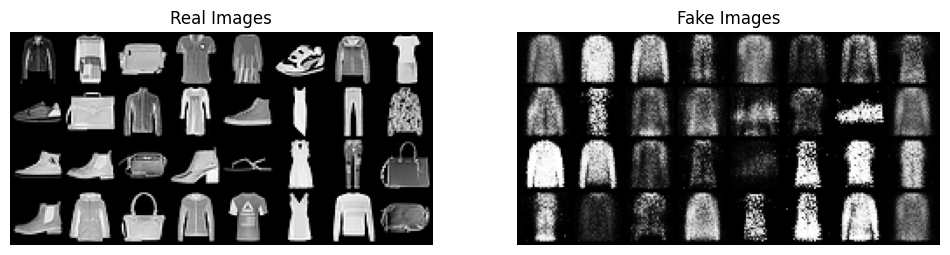

Epoch [11/50], d_loss: 0.9603, g_loss: 0.9533
Epoch [12/50], d_loss: 1.7003, g_loss: 1.1259
Epoch [13/50], d_loss: 0.8629, g_loss: 1.9120
Epoch [14/50], d_loss: 1.2297, g_loss: 1.2494
Epoch [15/50], d_loss: 0.8167, g_loss: 1.2362
Epoch [16/50], d_loss: 1.2479, g_loss: 1.2691
Epoch [17/50], d_loss: 1.2019, g_loss: 1.0524
Epoch [18/50], d_loss: 0.8397, g_loss: 1.3665
Epoch [19/50], d_loss: 1.4564, g_loss: 1.0256
Epoch [20/50], d_loss: 1.2925, g_loss: 1.0053


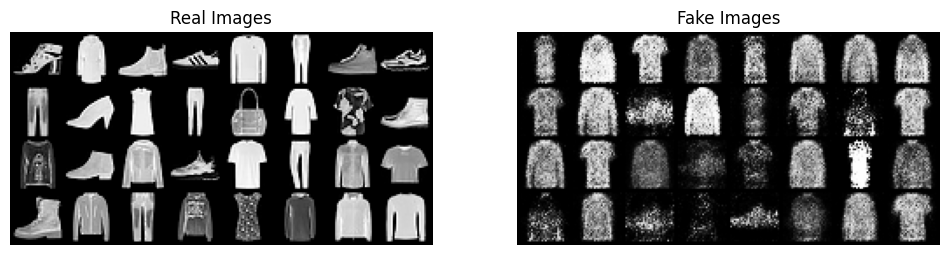

Epoch [21/50], d_loss: 1.0725, g_loss: 0.9849
Epoch [22/50], d_loss: 0.9671, g_loss: 1.1975
Epoch [23/50], d_loss: 1.0268, g_loss: 1.1320
Epoch [24/50], d_loss: 1.1444, g_loss: 1.4838
Epoch [25/50], d_loss: 0.8083, g_loss: 1.4556
Epoch [26/50], d_loss: 1.1330, g_loss: 1.2607
Epoch [27/50], d_loss: 1.1488, g_loss: 1.2549
Epoch [28/50], d_loss: 1.2584, g_loss: 1.2629
Epoch [29/50], d_loss: 1.3748, g_loss: 1.0803
Epoch [30/50], d_loss: 1.1398, g_loss: 1.3592


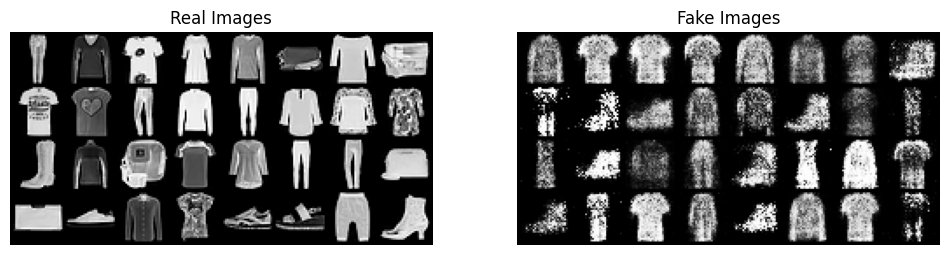

Epoch [31/50], d_loss: 1.2530, g_loss: 1.0480
Epoch [32/50], d_loss: 1.4514, g_loss: 1.0239
Epoch [33/50], d_loss: 1.1932, g_loss: 1.8950
Epoch [34/50], d_loss: 1.1322, g_loss: 1.1503
Epoch [35/50], d_loss: 1.0573, g_loss: 1.1528
Epoch [36/50], d_loss: 1.1719, g_loss: 0.9256
Epoch [37/50], d_loss: 1.2118, g_loss: 1.2030
Epoch [38/50], d_loss: 0.8485, g_loss: 1.4285
Epoch [39/50], d_loss: 1.3623, g_loss: 1.2441
Epoch [40/50], d_loss: 1.1385, g_loss: 1.0721


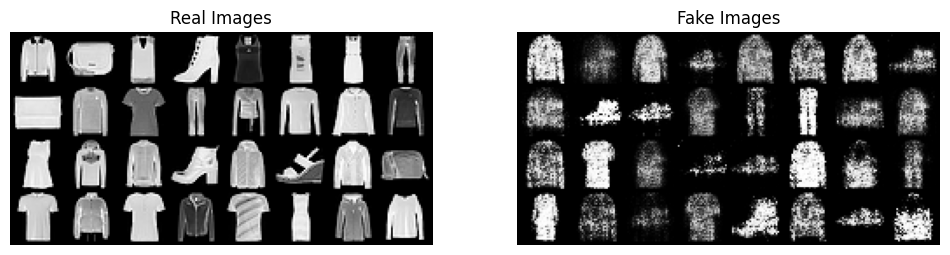

Epoch [41/50], d_loss: 1.0531, g_loss: 1.2009
Epoch [42/50], d_loss: 1.0929, g_loss: 1.0925
Epoch [43/50], d_loss: 1.2310, g_loss: 1.0852
Epoch [44/50], d_loss: 1.0276, g_loss: 1.2676
Epoch [45/50], d_loss: 1.1623, g_loss: 0.8566
Epoch [46/50], d_loss: 1.1152, g_loss: 0.8298
Epoch [47/50], d_loss: 1.1199, g_loss: 1.0134
Epoch [48/50], d_loss: 1.0679, g_loss: 1.0494
Epoch [49/50], d_loss: 1.5410, g_loss: 0.7146
Epoch [50/50], d_loss: 1.3369, g_loss: 1.0335


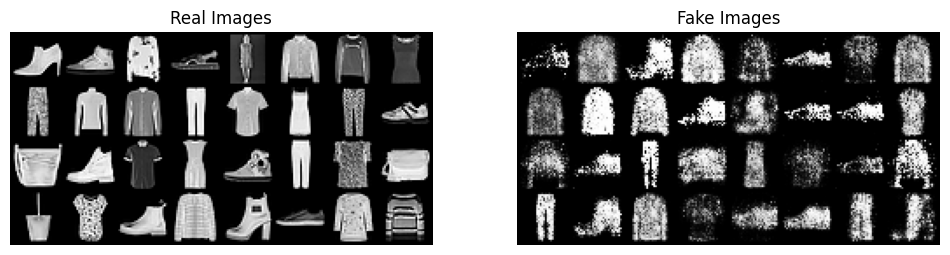

In [3]:
# Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision

# Data Preparation
# GANs are sensitive to data scale. We normalize images to a range of [-1, 1]
# because the Generator ends with a Tanh activation (which outputs -1 to 1).
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Automatically downloads the FashionMNIST dataset (60,000 images of clothing)
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Discriminator - its goal is to output a 1 for real images and a 0 for fake images.
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(784,512), # 784 = 28x28 pixels flattened
        nn.LeakyReLU(0.2), # LeakyReLU allows a small signal for negative values to keep learning active
        nn.Linear(512,256), # Single output: Real or Fake?
        nn.LeakyReLU(0.2), # Forces the output to be between 0 and 1 (probability))
        nn.Linear(256,1),
        nn.Sigmoid()


    )


  def forward(self, x):
    x = x.view(x.size(0),-1) # Flatten the 2D image into a 1D vector
    output = self.model(x)
    return output

# Generator - # It takes random noise (z) and tries to turn it into a realistic clothing image.
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(100,256), # Input is a 100-dimension vector of random noise
        nn.LeakyReLU(0.2),
        nn.Linear(256,512),
        nn.LeakyReLU(0.2),
        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),
        nn.Linear(1024,784), # Output is 784 pixels
        nn.Tanh() # Tanh centers data around 0, helping GAN stability
    )

  def forward(self, z):
    output = self.model(z)
    output = output.view(output.size(0),1,28,28) # Reshape vector back into a 28x28 image
    return output


D = Discriminator()
G=Generator()
criterion = nn.BCELoss()
d_optimizer = optim.Adam(D.parameters(), lr=0.0002)
g_optimizer = optim.Adam(G.parameters(), lr=0.0002)

epochs = 50

# Training Loop
for epoch in range(epochs):
    for i, (images, _) in enumerate(train_loader):

      # Train the discriminator
      D.zero_grad()
      real_images = images
      real_labels = torch.ones(images.size(0), 1) # Labels for real images = 1
      real_outputs = D(real_images)
      d_loss_real = criterion(real_outputs, real_labels)

      z = torch.randn(images.size(0), 100) # Create random noise
      fake_images = G(z) # Generator makes fake images
      fake_labels = torch.zeros(images.size(0), 1) # Labels for fake images = 0
      fake_outputs = D(fake_images) # Detach prevents updating Generator here
      d_loss_fake = criterion(fake_outputs, fake_labels)

      d_loss = d_loss_real + d_loss_fake
      d_loss.backward()
      d_optimizer.step()

      # Train Generator
      G.zero_grad()
      z = torch.randn(images.size(0), 100)
      fake_images = G(z)
      outputs = D(fake_images) # Now we want the Discriminator to guess "1" (Real) for these fakes
      g_loss = criterion(outputs, real_labels) # We use real_labels to trick the Generator into improving

      g_loss.backward()
      g_optimizer.step()

    print(f'Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}')

    # Visualize Progress
    if (epoch + 1) % 10 == 0:
      real_images_grid = torchvision.utils.make_grid(real_images, normalize=True)
      fake_images_grid = torchvision.utils.make_grid(fake_images, normalize=True)

      plt.figure(figsize=(12,6))
      plt.subplot(1,2,1)
      plt.title("Real Images")
      plt.imshow(real_images_grid.permute(1,2,0), cmap='gray')
      plt.axis('off')

      plt.subplot(1,2,2)
      plt.title("Fake Images")
      plt.imshow(fake_images_grid.permute(1,2,0), cmap='gray')
      plt.axis('off')

      plt.show()